<a href="https://colab.research.google.com/github/mvashi-sonic/AICapstoneProj/blob/dev/capstone_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Do this and restart to get rid of the annoying error, restart after

In [1]:
!pip uninstall -y torchvision

Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128


Mount the drive

In [1]:
from google.colab import drive

# 1. Mount your Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


Load Dataset

In [ ]:
import os
os.environ["TRANSFORMERS_NO_TORCHVISION"] = "1"

import torch

!pip install datasets
from datasets import load_dataset
from datasets import Dataset


data = load_dataset(
    "json",
    data_files="/content/drive/MyDrive/AI_capstone_training_data/all_records_final_formatted_3.json"
)

dataset = Dataset.from_list(data["train"]["All_Records"])
print (dataset.column_names)

In [11]:
from collections import Counter

counts = Counter(dataset["label"])

print("Negative (0):", counts["0"])
print("Positive (1):", counts["1"])

Negative (0): 60866
Positive (1): 64070


Test, Train, Validation Split

In [14]:
#Test Train Split
from datasets import DatasetDict

# 2. First split: Isolate the final test set (15%)
train_testvalid = dataset.train_test_split(test_size=0.15, seed=42)

# 3. Second split: Split the temporary training set into train (70%) and validation (15%)
test_valid = train_testvalid["train"].train_test_split(test_size=0.176, seed=42)

# 4. Combine everything into a clean DatasetDict
final_dataset = DatasetDict({
    "train": test_valid["train"],
    "validation": test_valid["test"],  # The 'test' of the second split is your validation set
    "test": train_testvalid["test"]
})

print(len(test_valid["train"]))
print(len(test_valid["test"]))
print(len(train_testvalid["test"]))

from collections import Counter

counts = Counter(test_valid["train"]["label"])

print("Negative (0):", counts["0"])
print("Positive (1):", counts["1"])

counts_t = Counter(test_valid["test"]["label"])

print("Negative t (0):", counts_t["0"])
print("Positive t(1):", counts_t["1"])

counts_v = Counter(train_testvalid["test"]["label"])

print("Negative v(0):", counts_v["0"])
print("Positive v(1):", counts_v["1"])

87504
18691
18741
Negative (0): 42529
Positive (1): 44975
Negative t (0): 9154
Positive t(1): 9537
Negative v(0): 9183
Positive v(1): 9558


Finbert and Tokenizer

In [ ]:
#Load Finbert
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification

MODEL_NAME = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True
)

Tokenize Function

In [15]:
#Tokenize
def tokenize(example):

    return tokenizer(
        example["question"],
        example["reference"],
        truncation=True,
        padding="max_length",
        #padding=False,
        max_length=512
    )

Tokenize

In [ ]:
#print(test_valid["train"].column_names)

train_ds = test_valid["train"].map(tokenize, batched=True)
valid_ds = train_testvalid["test"].map(tokenize, batched=True)


test_ds = test_valid["test"].map(tokenize, batched=True)

In [29]:
train_ds.set_format("torch")
valid_ds.set_format("torch")

test_ds.set_format("torch")

Update Column Name For Pytorch

In [30]:
train_ds = train_ds.rename_column("label", "labels")
valid_ds = valid_ds.rename_column("label", "labels")

test_ds = test_ds.rename_column("label", "labels")

In [31]:
columns = [
    "input_ids",
    "attention_mask",
    "token_type_ids",
    "labels"
]


train_ds.set_format(
    type="torch",
    columns=columns
)

valid_ds.set_format(
    type="torch",
    columns=columns
)

test_ds.set_format(
    type="torch",
    columns=columns
)


Convert Labels To Int

In [ ]:
def fix_labels(example):
    return {
        "labels": int(example["labels"])
    }

train_ds = train_ds.map(fix_labels)
valid_ds = valid_ds.map(fix_labels)

test_ds = test_ds.map(fix_labels)

DataLoader

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=32
)

test_loader = DataLoader(
    valid_ds,
    batch_size=32
)

batch = next(iter(train_loader))

for k, v in batch.items():
    print(k, type(v))

In [ ]:
import torch
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

In [23]:
from torch.optim import AdamW
optimizer = AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

Train The Model

In [ ]:
from tqdm.auto import tqdm
#print(batch)

EPOCHS = 2

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    progress = tqdm(train_loader)

    for batch in progress:
        #for k, v in batch.items():
         # print(k, type(v))
        # Move tensors to GPU
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)

        loss = outputs.loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        progress.set_description(
            f"Epoch {epoch+1}"
        )

        progress.set_postfix(
            loss=loss.item()
        )

    print(
        f"Training Loss: {total_loss/len(train_loader):.4f}"
    )

Save The Model

In [25]:
model.save_pretrained(
    "finbert_relevance_mv_final"
)

tokenizer.save_pretrained(
    "finbert_relevance_mv_final"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('finbert_relevance_mv_final_2_without_any/tokenizer_config.json',
 'finbert_relevance_mv_final_2_without_any/tokenizer.json')

Load the Saved Model

In [26]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification


tokenizer = AutoTokenizer.from_pretrained(
    "./finbert_relevance_mv_final"
)

model = AutoModelForSequenceClassification.from_pretrained(
    "./finbert_relevance_mv_final"
)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [27]:
model = model.to(device)
print("Model device:")
print(next(model.parameters()).device)


Model device:
cuda:0


In [37]:
model.eval()

predictions = []
probabilities = []
true_labels = []


with torch.no_grad():

    #for batch in valid_loader:
    for batch in test_loader:
        labels = batch["labels"]

        inputs = {
            k: v.to(device)
            for k, v in batch.items()
            if k != "labels"
        }

        outputs = model(**inputs)

        probs = torch.softmax(
            outputs.logits,
            dim=1
        )

        preds = torch.argmax(
            probs,
            dim=1
        )

        predictions.extend(
            preds.cpu().numpy()
        )

        probabilities.extend(
            probs[:,1].cpu().numpy()
        )

        true_labels.extend(
            labels.numpy()
        )

ROC-AUC: 0.9994


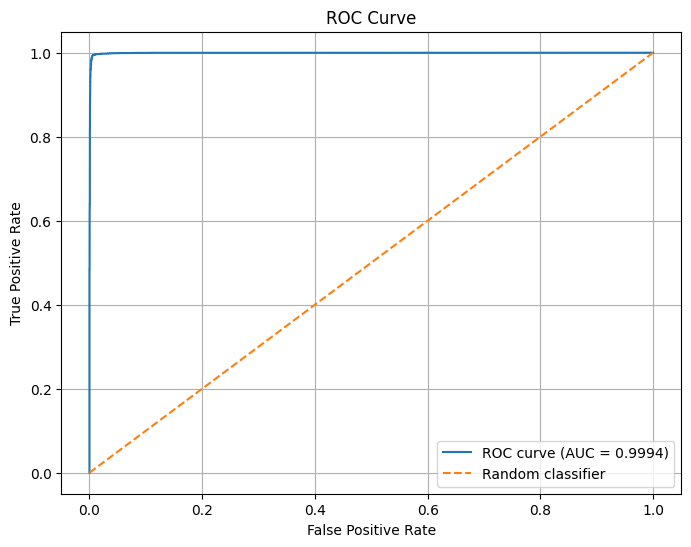

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    true_labels,
    probabilities
)

# Calculate AUC
auc_score = roc_auc_score(
    true_labels,
    probabilities
)

print(f"ROC-AUC: {auc_score:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC curve (AUC = {auc_score:.4f})"
)

# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [ ]:
!nvidia-smi

Tue Aug  4 19:51:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P0             50W /  400W |    5046MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [20]:
print(next(model.parameters()).device)


cuda:0


In [39]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

accuracy = accuracy_score(
    true_labels,
    predictions
)

f1 = f1_score(
    true_labels,
    predictions
)

print("Accuracy:", accuracy)
print("F1 Score:", f1)

print(
    classification_report(
        true_labels,
        predictions
    )
)
# Confusion Matrix
cm = confusion_matrix(
    true_labels,
    predictions
)

print("\nConfusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

Accuracy: 0.9937570033616135
F1 Score: 0.9938849108869493
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9183
           1       0.99      0.99      0.99      9558

    accuracy                           0.99     18741
   macro avg       0.99      0.99      0.99     18741
weighted avg       0.99      0.99      0.99     18741


Confusion Matrix:
[[9116   67]
 [  50 9508]]

True Negatives : 9116
False Positives: 67
False Negatives: 50
True Positives : 9508


In [25]:
#keep
#Copy data to drive
import os
import shutil
from google.colab import drive

def copy_to_drive(source_dir, destination_dir, file_suffix ):
  # 1. Define source and destination folders
  # Replace 'my_folder' with the exact folder path where your .json files currently are
  #source_dir = '.'
  # Replace 'My Drive/TargetFolder' with the Drive folder you want to copy to
  #destination_dir = '/content/drive/MyDrive/capstone_chunks_data_new'

  # Create the destination directory if it doesn't exist
  os.makedirs(destination_dir, exist_ok=True)

  # 2. Find and copy all .json files
  for filename in os.listdir(source_dir):
    if filename.endswith(file_suffix):
        source_file = os.path.join(source_dir, filename)
        destination_file = os.path.join(destination_dir, filename)

        shutil.copy2(source_file, destination_file)
        print(f"Copied: {filename}")

  print("All files copied successfully!")

copy_to_drive("./finbert_relevance_mv_final_2_without_any","/content/drive/MyDrive/AI_Capstone_Model_Final",".safetensors")




Copied: model.safetensors
All files copied successfully!
